In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
results = pd.read_csv("../data/processed/cleaned_results.csv")

In [3]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,result_label
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,Draw,0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,Home Win,1
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,Home Win,1
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,Draw,0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,Home Win,1


In [4]:
results["date"] = pd.to_datetime(results["date"])

In [5]:
results.shape

(49477, 11)

In [7]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49477 entries, 0 to 49476
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          49477 non-null  datetime64[ns]
 1   home_team     49477 non-null  object        
 2   away_team     49477 non-null  object        
 3   home_score    49433 non-null  float64       
 4   away_score    49433 non-null  float64       
 5   tournament    49477 non-null  object        
 6   city          49477 non-null  object        
 7   country       49477 non-null  object        
 8   neutral       49477 non-null  bool          
 9   result        49477 non-null  object        
 10  result_label  49477 non-null  int64         
dtypes: bool(1), datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 3.8+ MB


In [8]:
results.describe()

,date,home_score,away_score,result_label
count,49477,49433.000000,49433.000000,49477.000000
mean,1994-05-22 13:38:00.550558720,1.757490,1.181822,0.207450
min,1872-11-30 00:00:00,0.000000,0.000000,-1.000000
25%,1980-09-09 00:00:00,1.000000,0.000000,-1.000000
50%,2000-07-15 00:00:00,1.000000,1.000000,0.000000
75%,2013-07-15 00:00:00,2.000000,2.000000,1.000000
max,2026-06-27 00:00:00,31.000000,21.000000,1.000000
std,NaN,1.774299,1.401856,0.853729


In [9]:
results["result"].value_counts()

result
Home Win    24227
Away Win    13963
Draw        11287
Name: count, dtype: int64

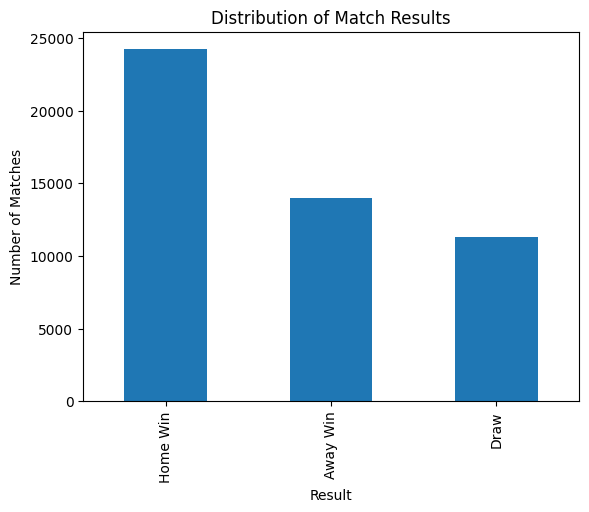

In [10]:
results["result"].value_counts().plot(kind="bar")

plt.title("Distribution of Match Results")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.show()

In [11]:
results["total_goals"] = results["home_score"] + results["away_score"]

In [12]:
results["total_goals"].mean()

2.939311795763963

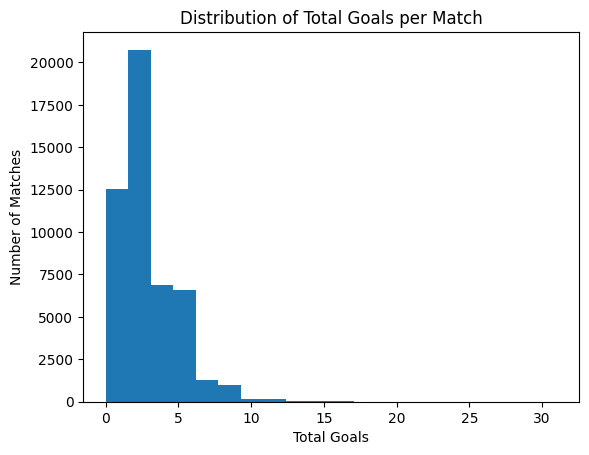

In [13]:
results["total_goals"].plot(kind="hist", bins=20)

plt.title("Distribution of Total Goals per Match")
plt.xlabel("Total Goals")
plt.ylabel("Number of Matches")
plt.show()

In [14]:
world_cup = results[results["tournament"] == "FIFA World Cup"]

In [15]:
world_cup.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,result_label,total_goals
1490,1930-07-13,Belgium,United States,0.0,3.0,FIFA World Cup,Montevideo,Uruguay,True,Away Win,-1,3.0
1491,1930-07-13,France,Mexico,4.0,1.0,FIFA World Cup,Montevideo,Uruguay,True,Home Win,1,5.0
1492,1930-07-14,Brazil,Yugoslavia,1.0,2.0,FIFA World Cup,Montevideo,Uruguay,True,Away Win,-1,3.0
1493,1930-07-14,Peru,Romania,1.0,3.0,FIFA World Cup,Montevideo,Uruguay,True,Away Win,-1,4.0
1494,1930-07-15,Argentina,France,1.0,0.0,FIFA World Cup,Montevideo,Uruguay,True,Home Win,1,1.0


In [16]:
world_cup.shape

(1036, 12)

In [17]:
home_wins = world_cup[world_cup["home_score"] > world_cup["away_score"]]["home_team"]
away_wins = world_cup[world_cup["away_score"] > world_cup["home_score"]]["away_team"]

all_winners = pd.concat([home_wins, away_wins])

top_winners = all_winners.value_counts().head(10)

top_winners

Brazil         76
Germany        69
Argentina      48
Italy          45
France         40
England        33
Spain          31
Netherlands    30
Uruguay        25
Belgium        21
Name: count, dtype: int64

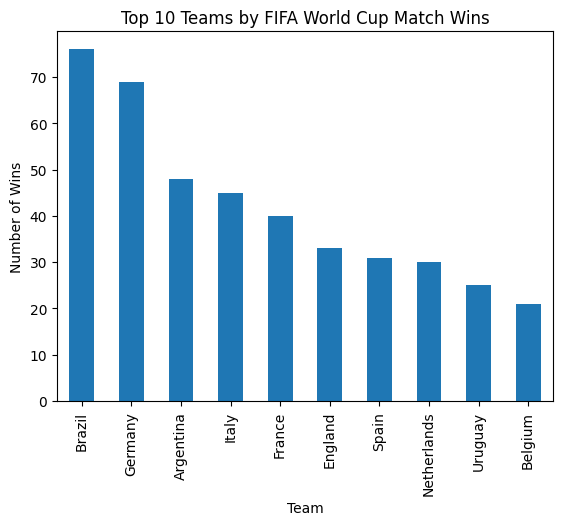

In [18]:
top_winners.plot(kind="bar")

plt.title("Top 10 Teams by FIFA World Cup Match Wins")
plt.xlabel("Team")
plt.ylabel("Number of Wins")
plt.show()

In [19]:
home_goals = world_cup.groupby("home_team")["home_score"].sum()
away_goals = world_cup.groupby("away_team")["away_score"].sum()

total_goals_by_team = home_goals.add(away_goals, fill_value=0)

top_goal_teams = total_goals_by_team.sort_values(ascending=False).head(10)

top_goal_teams

Germany        239.0
Brazil         238.0
Argentina      155.0
France         139.0
Italy          128.0
Spain          108.0
England        108.0
Netherlands     98.0
Uruguay         90.0
Hungary         87.0
dtype: float64

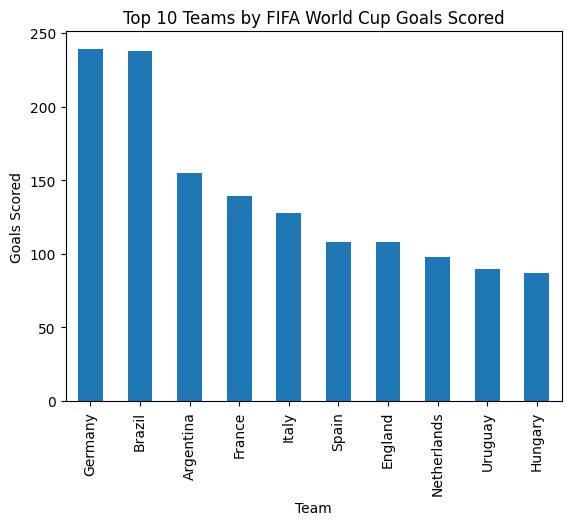

In [20]:
top_goal_teams.plot(kind="bar")

plt.title("Top 10 Teams by FIFA World Cup Goals Scored")
plt.xlabel("Team")
plt.ylabel("Goals Scored")
plt.show()

In [21]:
avg_goals_by_tournament = results.groupby("tournament")["total_goals"].mean().sort_values(ascending=False).head(10)

avg_goals_by_tournament

tournament
International Tournament of Peoples, Cultures and Tribes    9.857143
East Asian Games                                            7.235294
Inter-Allied Games                                          6.692308
Tri-Nations Cup                                             6.500000
Benedikt Fontana Cup                                        6.000000
Atlantic Heritage Cup                                       6.000000
Évence Coppée Trophy                                        6.000000
South Pacific Games                                         5.912195
Tynwald Hill Tournament                                     5.833333
GaNEFo                                                      5.785714
Name: total_goals, dtype: float64

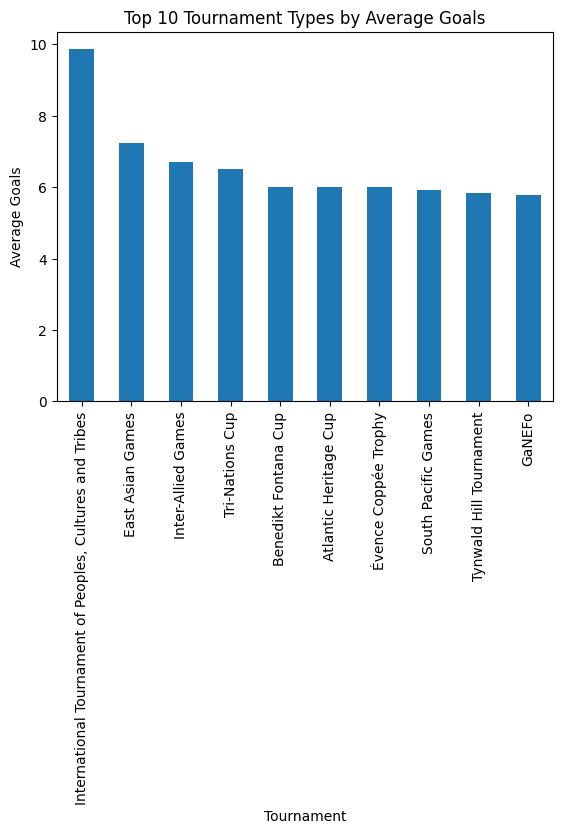

In [22]:
avg_goals_by_tournament.plot(kind="bar")

plt.title("Top 10 Tournament Types by Average Goals")
plt.xlabel("Tournament")
plt.ylabel("Average Goals")
plt.show()